# 🚗 Used Car Price Prediction: ML for Consumer Protection & Market Transparency

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Predicting used car prices from vehicle specifications to support fair pricing and consumer protection  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for predicting used car prices using vehicle age, mileage, engine specs, fuel type, and transmission. The model supports **fair pricing assessment**, **consumer protection**, and **automotive market analytics**.

### Government Policy Context
- **ACCC** — Consumer protection, misleading pricing claims, lemon laws enforcement
- **ABS** — CPI motor vehicle component, used car price index
- **Department of Infrastructure** — Vehicle registration data, fleet composition analytics
- **State Consumer Affairs** — Used car dealer compliance, cooling-off period enforcement
- **Green Vehicle Guide** — Fuel efficiency, emissions standards, EV transition policy

### Analytical Framework
| Prediction | Application | Stakeholder |
|-----------|-------------|-------------|
| Price significantly above predicted | Consumer overcharging alert | ACCC / consumer affairs |
| Price near predicted | Fair market value confirmation | Buyer / seller |
| Price below predicted | Potential hidden issues, bargain detection | Consumer / dealer |
| Depreciation curve | Fleet management, residual value forecasting | Finance / leasing |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY — REGRESSION NOTEBOOK")
print("=" * 60)


ENVIRONMENT READY — REGRESSION NOTEBOOK


In [2]:
data_path = None
all_csvs = []
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv'):
            all_csvs.append(full_path)

if len(all_csvs) == 0:
    raise FileNotFoundError("No CSV found")

data_path = max(all_csvs, key=lambda p: os.path.getsize(p))
df = pd.read_csv(data_path, encoding='latin-1')
print(f"\nUsing: {data_path}")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

if len(df) > 30000:
    df = df.sample(n=30000, random_state=42).reset_index(drop=True)
    print(f"Sampled to 30,000 rows")


  Found: /kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/car data.csv
  Found: /kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/car details v4.csv
  Found: /kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/CAR DETAILS FROM CAR DEKHO.csv
  Found: /kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/Car details v3.csv

Using: /kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/Car details v3.csv
Loaded: 8,128 rows x 13 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f"  {i:2d}. {col:25s} | {str(dtype):10s} | unique={nuniq:5d} | nulls={nulls:3d} | eg: {sample_val}")
df.head()


COLUMN SUMMARY
   0. name                      | object     | unique= 2058 | nulls=  0 | eg: Maruti Swift Dzire VDI
   1. year                      | int64      | unique=   29 | nulls=  0 | eg: 2014
   2. selling_price             | int64      | unique=  677 | nulls=  0 | eg: 450000
   3. km_driven                 | int64      | unique=  921 | nulls=  0 | eg: 145500
   4. fuel                      | object     | unique=    4 | nulls=  0 | eg: Diesel
   5. seller_type               | object     | unique=    3 | nulls=  0 | eg: Individual
   6. transmission              | object     | unique=    2 | nulls=  0 | eg: Manual
   7. owner                     | object     | unique=    5 | nulls=  0 | eg: First Owner
   8. mileage                   | object     | unique=  393 | nulls=221 | eg: 23.4 kmpl
   9. engine                    | object     | unique=  121 | nulls=221 | eg: 1248 CC
  10. max_power                 | object     | unique=  322 | nulls=215 | eg: 74 bhp
  11. torque           

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


## 2. Target Variable Analysis

In [4]:
target_candidates = ['selling_price', 'Selling_Price', 'price', 'Price', 'sold_price',
                     'target', 'Target', 'present_price', 'Cost']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    for col in df.columns:
        if 'price' in col.lower() or 'cost' in col.lower():
            if df[col].dtype in ['int64', 'float64'] and df[col].nunique() > 50:
                target_col = col
                print(f"Auto-detected: '{target_col}'")
                break

if target_col is None:
    raise ValueError("Could not identify target")

# Remove zero/negative prices
df = df[df[target_col] > 0].reset_index(drop=True)

print(f"\nTarget statistics:")
print(df[target_col].describe())
print(f"\nSkewness: {df[target_col].skew():.3f}")


Found target: 'selling_price'

Target statistics:
count    8.128000e+03
mean     6.382718e+05
std      8.062534e+05
min      2.999900e+04
25%      2.549990e+05
50%      4.500000e+05
75%      6.750000e+05
max      1.000000e+07
Name: selling_price, dtype: float64

Skewness: 4.194


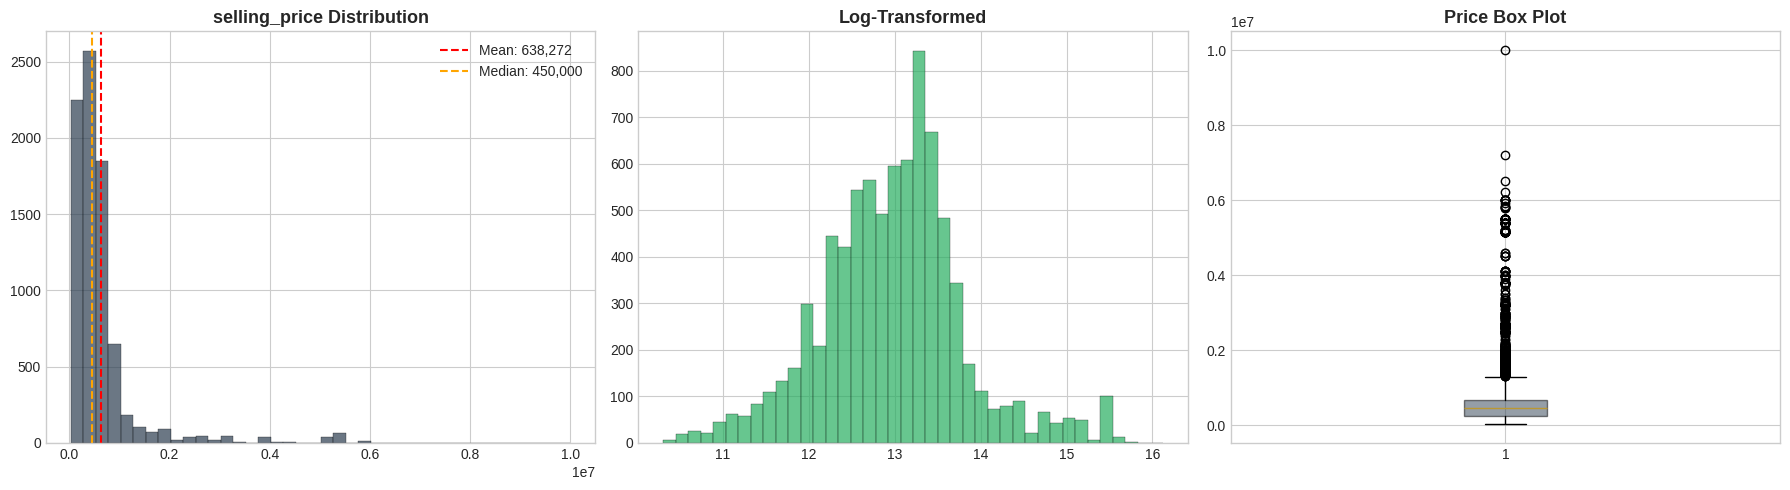

AU context: ~1.1M used cars sold annually in Australia (ABS Motor Vehicle Census).
Used car prices surged 30%+ during COVID-19 supply chain disruptions.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(df[target_col], bins=40, color='#2c3e50', edgecolor='black', linewidth=0.3, alpha=0.7)
axes[0].set_title(f'{target_col} Distribution', fontsize=13, fontweight='bold')
axes[0].axvline(df[target_col].mean(), color='red', linestyle='--', label=f'Mean: {df[target_col].mean():,.0f}')
axes[0].axvline(df[target_col].median(), color='orange', linestyle='--', label=f'Median: {df[target_col].median():,.0f}')
axes[0].legend()

axes[1].hist(np.log1p(df[target_col]), bins=40, color='#27ae60', edgecolor='black', linewidth=0.3, alpha=0.7)
axes[1].set_title('Log-Transformed', fontsize=13, fontweight='bold')

axes[2].boxplot(df[target_col], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#2c3e50', alpha=0.5))
axes[2].set_title('Price Box Plot', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("AU context: ~1.1M used cars sold annually in Australia (ABS Motor Vehicle Census).")
print("Used car prices surged 30%+ during COVID-19 supply chain disruptions.")


## 3. Exploratory Data Analysis

Numeric features (3): ['year', 'km_driven', 'seats']


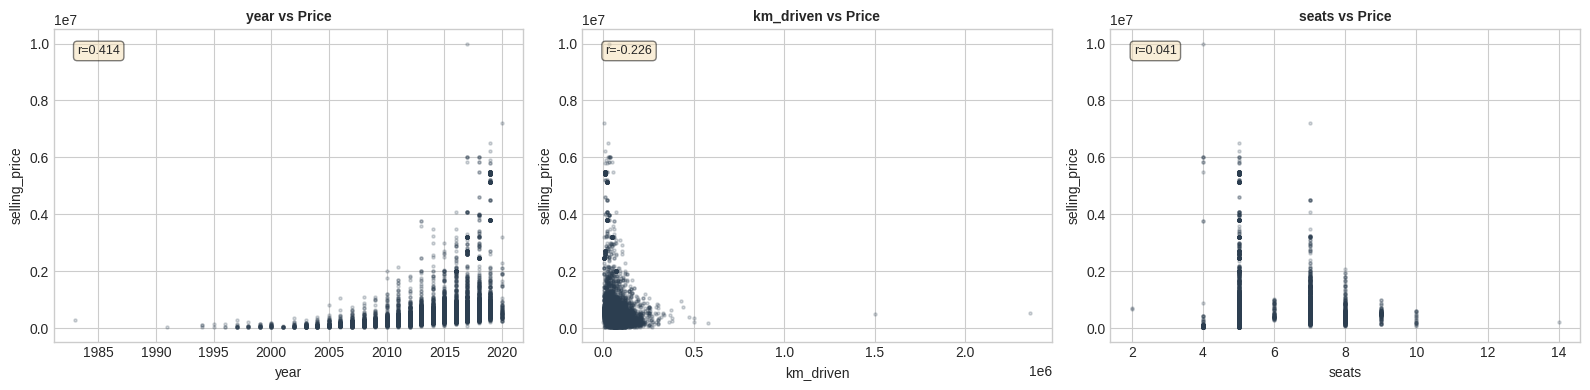

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(target_col)
numeric_cols = [c for c in numeric_cols if c.lower() not in ['unnamed: 0', 'index', 'id']]
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols[:10]}")

plot_cols = numeric_cols[:6]
if len(plot_cols) > 0:
    n_rows_p = max(1, (len(plot_cols) + 2) // 3)
    fig, axes = plt.subplots(n_rows_p, 3, figsize=(16, 4 * n_rows_p))
    axes = axes.flatten()
    for i, col in enumerate(plot_cols):
        axes[i].scatter(df[col], df[target_col], alpha=0.2, s=5, color='#2c3e50')
        axes[i].set_xlabel(col); axes[i].set_ylabel(target_col)
        axes[i].set_title(f'{col} vs Price', fontsize=10, fontweight='bold')
        corr_val = df[[col, target_col]].corr().iloc[0, 1]
        axes[i].text(0.05, 0.95, f'r={corr_val:.3f}', transform=axes[i].transAxes, fontsize=9,
                     va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout(); plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight'); plt.show()


Categorical features: ['fuel', 'seller_type', 'transmission', 'owner']


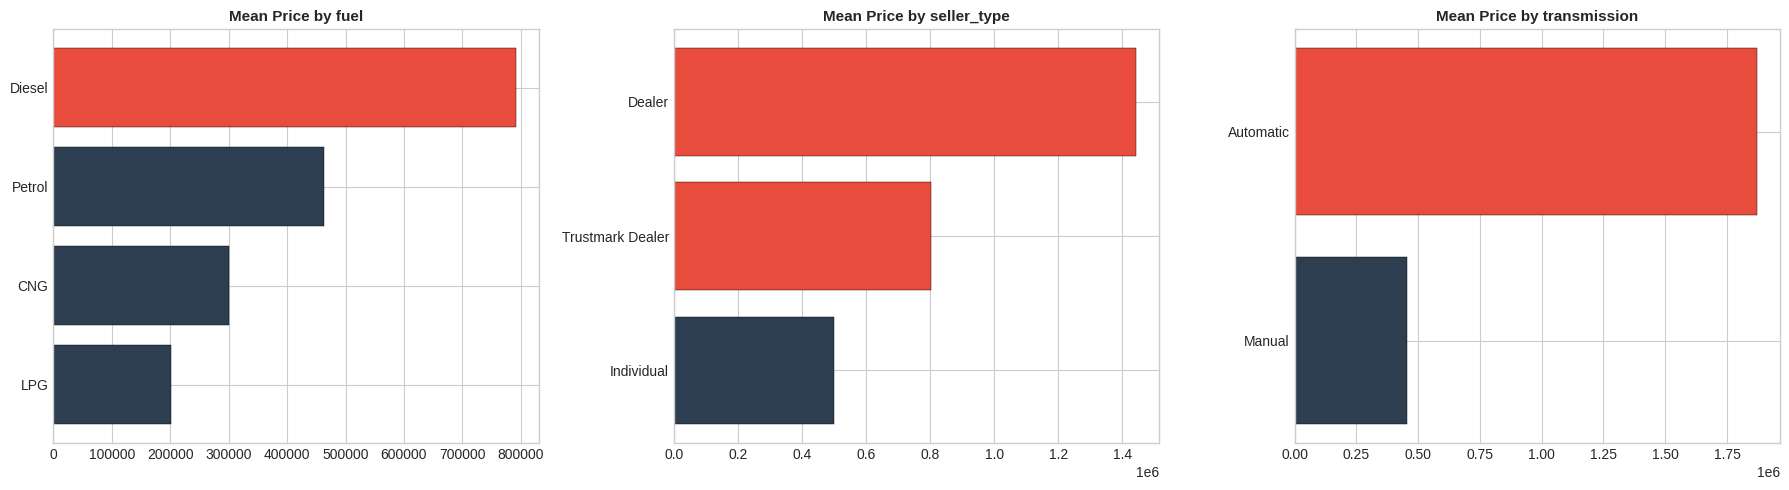

In [7]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols: cat_cols.remove(target_col)
cat_cols = [c for c in cat_cols if df[c].nunique() <= 15 and 'name' not in c.lower()]
print(f"Categorical features: {cat_cols}")

if len(cat_cols) > 0:
    fig, axes = plt.subplots(1, min(len(cat_cols), 3), figsize=(6 * min(len(cat_cols), 3), 5))
    if not isinstance(axes, np.ndarray): axes = [axes]
    for i, col in enumerate(cat_cols[:3]):
        means = df.groupby(col)[target_col].mean().sort_values()
        if len(means) > 15: means = means.tail(15)
        clrs = ['#e74c3c' if v > df[target_col].mean() else '#2c3e50' for v in means.values]
        axes[i].barh(means.index.astype(str), means.values, color=clrs, edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'Mean Price by {col}', fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.savefig('categorical_prices.png', dpi=150, bbox_inches='tight'); plt.show()


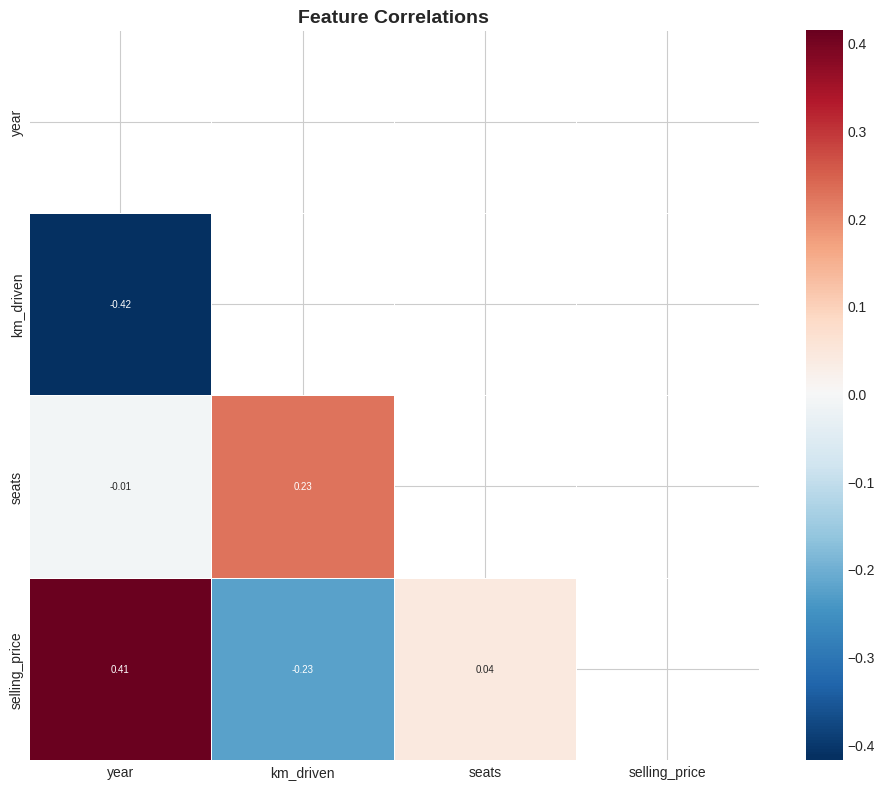

In [8]:
if len(numeric_cols) > 1:
    corr_cols = numeric_cols[:10] + [target_col]
    corr = df[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
    ax.set_title('Feature Correlations', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()


## 4. Feature Engineering & Preprocessing

In [9]:
df_model = df.copy()

# Drop non-predictive columns
drop_cols = [c for c in df_model.columns if c.lower() in ['unnamed: 0', 'index', 'id']]
# Drop name/model columns with too many unique values
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col and df_model[col].nunique() > 50:
        drop_cols.append(col)
        print(f"  Dropping high-cardinality: '{col}' ({df_model[col].nunique()} unique)")

drop_cols = list(set(drop_cols))
if drop_cols:
    df_model.drop(columns=[c for c in drop_cols if c in df_model.columns], inplace=True)

# Encode categoricals
le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values

# Log transform target if skewed
use_log = False
if abs(pd.Series(y).skew()) > 1 and (y > 0).all():
    y = np.log1p(y)
    use_log = True
    print(f"\nApplied log1p transform (skew was {df[target_col].skew():.2f})")

# Impute NaN
if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())

# Feature engineering
composites_added = []

# Vehicle age
year_cols = [c for c in X.columns if c.lower() in ['year', 'model_year', 'year_of_manufacture']]
if year_cols:
    X['vehicle_age'] = 2024 - X[year_cols[0]]
    composites_added.append('vehicle_age')
    print("Created 'vehicle_age'")

# Mileage per year
km_cols = [c for c in X.columns if any(kw in c.lower() for kw in ['km', 'mileage', 'odometer', 'driven'])]
if km_cols and year_cols:
    X['km_per_year'] = X[km_cols[0]] / (X['vehicle_age'] + 1)
    composites_added.append('km_per_year')
    print("Created 'km_per_year'")

# High mileage flag
if km_cols:
    X['high_mileage'] = (X[km_cols[0]] > X[km_cols[0]].quantile(0.75)).astype(int)
    composites_added.append('high_mileage')
    print("Created 'high_mileage' (top 25%)")

print(f"\nEngineered: {len(composites_added)}")
print(f"Final: {X.shape}")


  Dropping high-cardinality: 'name' (2058 unique)
  Dropping high-cardinality: 'mileage' (393 unique)
  Dropping high-cardinality: 'engine' (121 unique)
  Dropping high-cardinality: 'max_power' (322 unique)
  Dropping high-cardinality: 'torque' (441 unique)
  Encoded 'fuel': 4 classes
  Encoded 'seller_type': 3 classes
  Encoded 'transmission': 2 classes
  Encoded 'owner': 5 classes

Applied log1p transform (skew was 4.19)
Created 'vehicle_age'
Created 'km_per_year'
Created 'high_mileage' (top 25%)

Engineered: 3
Final: (8128, 10)


## 5. Model Training & Cross-Validation

In [10]:
try:
    from xgboost import XGBRegressor
    print("XGBoost loaded")
except ImportError:
    XGBRegressor = None
try:
    from lightgbm import LGBMRegressor
    print("LightGBM loaded")
except ImportError:
    LGBMRegressor = None


XGBoost loaded
LightGBM loaded


In [11]:
models = {
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBRegressor is not None:
    models['XGBoost'] = XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1)
if LGBMRegressor is not None:
    models['LightGBM'] = LGBMRegressor(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1,
                                        force_col_wise=True)

kf = KFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_rmse, fold_mae, fold_r2 = [], [], []
    fold_preds = np.zeros(len(y))
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_arr)):
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_arr[train_idx], y[train_idx])
        y_pred = model_clone.predict(X_arr[val_idx])
        fold_preds[val_idx] = y_pred
        rmse = np.sqrt(mean_squared_error(y[val_idx], y_pred))
        mae = mean_absolute_error(y[val_idx], y_pred)
        r2 = r2_score(y[val_idx], y_pred)
        fold_rmse.append(rmse); fold_mae.append(mae); fold_r2.append(r2)
        print(f"  Fold {fold_idx+1}: RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {'rmse_mean': np.mean(fold_rmse), 'mae_mean': np.mean(fold_mae),
        'r2_mean': np.mean(fold_r2), 'r2_std': np.std(fold_r2),
        'time': elapsed, 'oof_preds': fold_preds}
    print(f"  -- RMSE: {np.mean(fold_rmse):.4f}  MAE: {np.mean(fold_mae):.4f}  R2: {np.mean(fold_r2):.4f}  Time: {elapsed:.2f}s")



Training: Ridge
  Fold 1: RMSE=0.4477  MAE=0.3458  R2=0.7132
  Fold 2: RMSE=0.4332  MAE=0.3371  R2=0.7327
  Fold 3: RMSE=0.4418  MAE=0.3400  R2=0.7255
  -- RMSE: 0.4409  MAE: 0.3409  R2: 0.7238  Time: 0.03s

Training: Random Forest
  Fold 1: RMSE=0.3917  MAE=0.2873  R2=0.7805
  Fold 2: RMSE=0.3748  MAE=0.2769  R2=0.7999
  Fold 3: RMSE=0.3830  MAE=0.2808  R2=0.7937
  -- RMSE: 0.3832  MAE: 0.2817  R2: 0.7914  Time: 2.09s

Training: XGBoost
  Fold 1: RMSE=0.3818  MAE=0.2810  R2=0.7914
  Fold 2: RMSE=0.3653  MAE=0.2743  R2=0.8100
  Fold 3: RMSE=0.3795  MAE=0.2773  R2=0.7974
  -- RMSE: 0.3755  MAE: 0.2776  R2: 0.7996  Time: 0.32s

Training: LightGBM
  Fold 1: RMSE=0.3778  MAE=0.2827  R2=0.7957
  Fold 2: RMSE=0.3558  MAE=0.2710  R2=0.8197
  Fold 3: RMSE=0.3677  MAE=0.2748  R2=0.8099
  -- RMSE: 0.3671  MAE: 0.2762  R2: 0.8085  Time: 0.39s


## 6. Model Comparison & Selection

In [12]:
summary_rows = [{'Model': mn, 'RMSE': f"{res['rmse_mean']:.4f}",
    'MAE': f"{res['mae_mean']:.4f}",
    'R2': f"{res['r2_mean']:.4f} +/- {res['r2_std']:.4f}",
    'Time': f"{res['time']:.2f}s", 'sort_val': res['r2_mean']}
    for mn, res in results.items()]
summary_df = pd.DataFrame(summary_rows).sort_values('sort_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 80)
print(summary_df[['Model', 'RMSE', 'MAE', 'R2', 'Time']].to_string(index=False))
print("=" * 80)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
        Model   RMSE    MAE                R2  Time
     LightGBM 0.3671 0.2762 0.8085 +/- 0.0098 0.39s
      XGBoost 0.3755 0.2776 0.7996 +/- 0.0078 0.32s
Random Forest 0.3832 0.2817 0.7914 +/- 0.0081 2.09s
        Ridge 0.4409 0.3409 0.7238 +/- 0.0081 0.03s

Best model: LightGBM


## 7. Residual Analysis

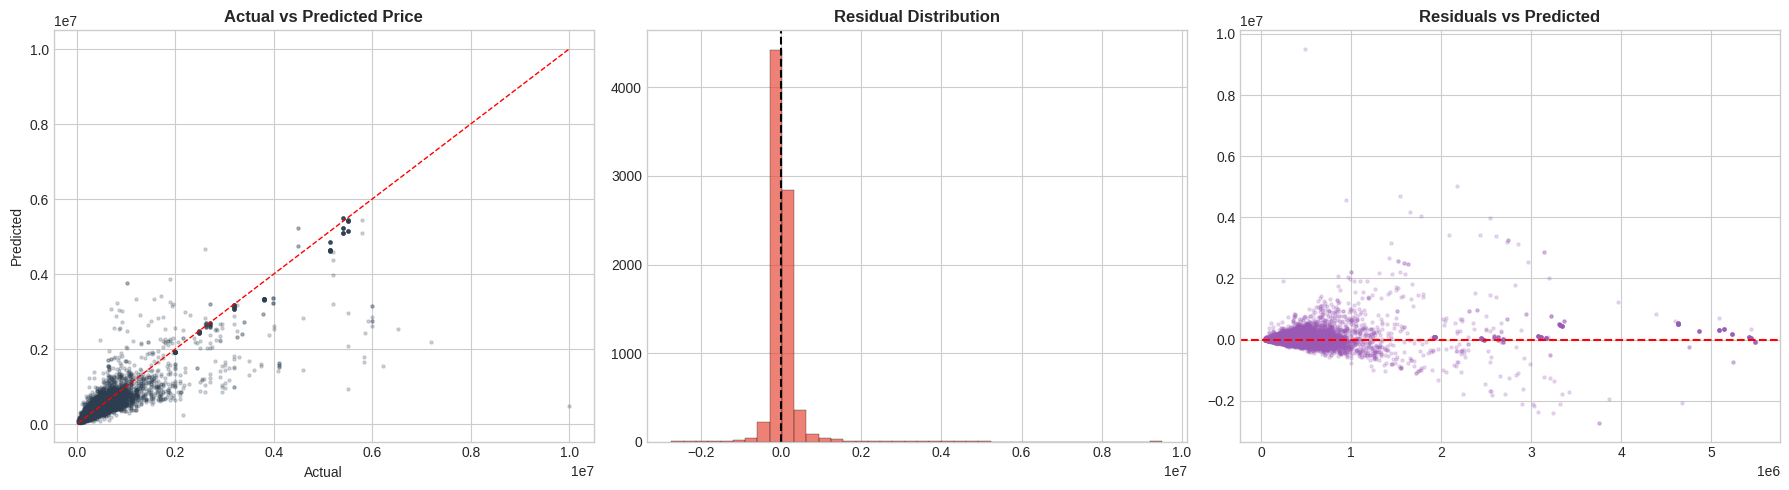

Mean residual: 37,920
Std residual:  336,577


In [13]:
best_preds = results[best_model_name]['oof_preds']
if use_log:
    y_plot = np.expm1(y); pred_plot = np.expm1(best_preds)
else:
    y_plot = y; pred_plot = best_preds
residuals = y_plot - pred_plot

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(y_plot, pred_plot, alpha=0.2, s=5, color='#2c3e50')
lims = [min(y_plot.min(), pred_plot.min()), max(y_plot.max(), pred_plot.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_title('Actual vs Predicted Price', fontweight='bold')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')

axes[1].hist(residuals, bins=40, color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=0.3)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residual Distribution', fontweight='bold')

axes[2].scatter(pred_plot, residuals, alpha=0.2, s=5, color='#9b59b6')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuals vs Predicted', fontweight='bold')
plt.tight_layout(); plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"Mean residual: {np.mean(residuals):,.0f}")
print(f"Std residual:  {np.std(residuals):,.0f}")


## 8. Feature Importance & Policy Insights

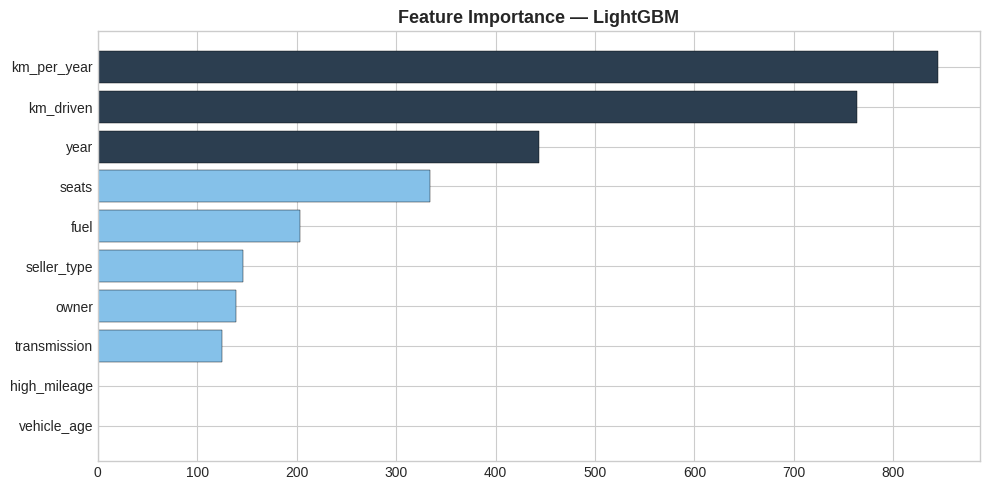

TOP 5 PRICE DRIVERS
  km_per_year                845.0000
  km_driven                  764.0000
  year                       444.0000
  seats                      334.0000
  fuel                       203.0000

Market insight: Vehicle age and mileage are the dominant depreciation factors.
Fuel type increasingly important with EV transition (Green Vehicle Guide).


In [14]:
tree_models = {k: v for k, v in models.items() if k != 'Ridge'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['r2_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(5, len(feat_imp) * 0.5)))
    colors_imp = ['#2c3e50' if imp > feat_imp['Importance'].quantile(0.75) else '#85c1e9' for imp in feat_imp['Importance']]
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 PRICE DRIVERS")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:25s}  {row['Importance']:.4f}")
    print("\nMarket insight: Vehicle age and mileage are the dominant depreciation factors.")
    print("Fuel type increasingly important with EV transition (Green Vehicle Guide).")


## 9. Deployment Readiness

In [15]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  RMSE:                 {best_res['rmse_mean']:.4f}")
print(f"  MAE:                  {best_res['mae_mean']:.4f}")
print(f"  R-squared:            {best_res['r2_mean']:.4f}")
if use_log: print(f"  (log-transformed target)")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  CV strategy:          3-fold KFold")
print("=" * 60)
checks = {
    'R2 > 0.60': best_res['r2_mean'] > 0.60,
    'Training time < 120s': best_res['time'] < 120,
    'Cross-validated': True,
    'Residual analysis done': True,
    'Feature importance available': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    LightGBM
  RMSE:                 0.3671
  MAE:                  0.2762
  R-squared:            0.8085
  (log-transformed target)
  Training time:        0.4s
  Feature count:        10
  Dataset rows:         8,128
  CV strategy:          3-fold KFold

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] R2 > 0.60
  [pass] Training time < 120s
  [pass] Cross-validated
  [pass] Residual analysis done
  [pass] Feature importance available
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT


In [16]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: Dealer listings, auction results, registration databases
   Ingestion: Web scraping API -> Azure Data Factory -> Fabric Lakehouse
   Feature store: Fabric gold layer (specs, mileage, condition, market)
   Schedule: Daily listing updates + weekly market index calculation

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time at listing submission + consumer price check
   Output: Fair market value + confidence range + comparable vehicles
   Dashboard: Power BI (market trends, regional pricing, depreciation)

3. INTEGRATION POINTS
   ACCC: Price fairness monitoring for used car market
   Consumer affairs: Overpricing alert for regulatory action
   Dealers: Automated valuation at trade-in
   Insurance: Agreed value calculation for comprehensive policies
   Finance: Residual value for car loans and leasing

4. GOVERNANCE
   Consumer protection: Fair pricing, no misleading representations
   Transparency: Valuation methodology available to consumers
   Data quality: Validate against actual sale prices at auction
   Privacy: No personal data — vehicle specifications only

5. MONITORING & RETRAINING
   Drift: PSI on vehicle specs and market prices monthly
   Performance: MAE against actual sale prices monthly
   Retraining: Monthly with latest sales data
   Market shocks: Recalibrate for supply chain disruptions
   EV transition: Adjust for changing fuel type valuations

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: Dealer listings, auction results, registration databases
   Ingestion: Web scraping API -> Azure Data Factory -> Fabric Lakehouse
   Feature store: Fabric gold layer (specs, mileage, condition, market)
   Schedule: Daily listing updates + weekly market index calculation

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time at listing submission + consumer price check
   Output: Fair market value + confidence range + comparable vehicles
   Dashboard: Power BI (market trends, regional pricing, depreciation)

3. INTEGRATION POINTS
   ACCC: Price fairness monitoring for used car market
   Consumer affairs: Overpricing alert for regulatory action
   Dealers: Automated valuation at trade-in
   Insurance: Agreed value calculation for comprehensive policies
   Finance: Residual value for car loans and leasing

4. GOVERNANCE
   Consumer protection: Fair pricing, no misleading representations
   Transparency